# BÀI THỰC HÀNH TUẦN 2: LỰA CHỌN ĐẶC TRƯNG & GIẢM CHIỀU DỮ LIỆU
## MÔ HÌNH TINH GỌN: 2 PHƯƠNG PHÁP CHỌN ĐẶC TRƯNG & 2 PHƯƠNG PHÁP GIẢM CHIỀU

**Bộ dữ liệu:** Bank Marketing Dataset (UCI Machine Learning Repository)  
**Bài toán:** Dự đoán khách hàng có gửi tiền tiết kiệm có kỳ hạn hay không (`y`: *'yes'* $\rightarrow 1$, *'no'* $\rightarrow 0$).  

**Khung chương trình tinh gọn & trọng tâm:**
1. **Feature Selection (Lựa chọn đặc trưng - 2 Phương pháp đỉnh cao):**
   - **RFECV** (Wrapper Method): Loại bỏ đệ quy kết hợp kiểm định chéo K-Fold dựa trên mô hình tuyến tính.
   - **Random Forest Importance & `SelectFromModel`** (Embedded Method): Khai thác sức mạnh phi tuyến tính và tương tác đa biến trên dữ liệu bảng.
   - **Đối chiếu sự đồng thuận (Consensus):** Tìm ra tập đặc trưng "vàng" được cả 2 phương pháp cùng lựa chọn.
2. **Dimensionality Reduction (Giảm chiều dữ liệu - 2 Góc nhìn đối lập):**
   - **PCA** (Unsupervised - Không giám sát): Nén dữ liệu theo phương sai cực đại, khử tương quan đa biến.
   - **LDA** (Supervised - Có giám sát): Tối ưu hóa phân tách giữa 2 lớp khách hàng (đặc thù $k=1$ chiều).
3. **Benchmark Toàn Diện:** So sánh F1-Score (Deposit=Yes), ROC-AUC và tốc độ huấn luyện của 5 kịch bản trên tập Test thực tế.


---
## 1. THIẾT LẬP MÔI TRƯỜNG & TIỀN XỬ LÝ DỮ LIỆU

### 1.1. Import các thư viện chuyên dụng


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')  # Tắt các cảnh báo không cần thiết

import pandas as pd
import numpy as np
np.seterr(all='ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thuật toán Feature Selection (RFECV & SelectFromModel)
from sklearn.feature_selection import RFECV, SelectFromModel

# 2. Thuật toán Dimensionality Reduction (PCA & LDA)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# 3. Tiền xử lý, Chuẩn hóa & Chia tập
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

# 4. Mô hình học máy & Đo lường hiệu năng
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score

# Thiết lập giao diện đồ thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

print("✅ Đã nạp thành công toàn bộ thư viện cần thiết!")


✅ Đã nạp thành công toàn bộ thư viện cần thiết!


### 1.2. Nạp dữ liệu Bank Marketing và Mã hóa One-Hot Encoding

Dữ liệu `bank-full.csv` gồm **45,211 dòng** và **17 cột**:
- **7 biến số liên tục:** `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`.
- **9 biến phân loại (Categorical):** `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`.
- **Biến mục tiêu `y`:** Khách hàng có gửi tiết kiệm không (`'yes'` $\rightarrow 1$, `'no'` $\rightarrow 0$).

Ta dùng `pd.get_dummies(..., drop_first=True)` để biến đổi các cột chữ thành các cột nhị phân $0/1$. Sau khi mã hóa, không gian mở rộng lên **42 đặc trưng**.


In [2]:
# 1. Đọc dữ liệu Bank Marketing từ file cục bộ
df = pd.read_csv("bank-full.csv", sep=";")

print(f"Kích thước dữ liệu gốc: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print("")
print("Phân phối nhãn mục tiêu:")
print(df["y"].value_counts())

# 2. Mã hóa biến mục tiêu y: "yes" -> 1, "no" -> 0
y = df["y"].map({"yes": 1, "no": 0}).astype(int)

# 3. Mã hóa One-Hot Encoding cho các biến phân loại
X = pd.get_dummies(df.drop(columns=["y"]), drop_first=True, dtype=float)

# 4. Phân chia Train / Test (80% Train, 20% Test) có phân tầng (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 60)
print("✅ DỮ LIỆU ĐÃ MÃ HOÁ VÀ TÁCH TẬP THÀNH CÔNG:")
print(f"- Số đặc trưng sau One-Hot: {X.shape[1]} cột")
print(f"- Tập Train                : {X_train.shape[0]:,} dòng")
print(f"- Tập Test                 : {X_test.shape[0]:,} dòng")
print("=" * 60)


Kích thước dữ liệu gốc: 45,211 dòng × 17 cột

Phân phối nhãn mục tiêu:
y
no     39922
yes     5289
Name: count, dtype: int64
✅ DỮ LIỆU ĐÃ MÃ HOÁ VÀ TÁCH TẬP THÀNH CÔNG:
- Số đặc trưng sau One-Hot: 42 cột
- Tập Train                : 36,168 dòng
- Tập Test                 : 9,043 dòng


### 1.3. Chuẩn hóa thang đo (Feature Scaling) với `StandardScaler`

#### 📖 Bản chất toán học:
Công thức chuẩn hóa Z-score:
$$z = \frac{x - \mu}{\sigma}$$
* **$\mu = 0$**: Đặt tâm đối xứng về gốc tọa độ.
* **$\sigma = 1$**: San phẳng thang đo của các biến có giá trị lớn (`balance` hàng nghìn euro, `duration` hàng nghìn giây) và các biến nhị phân $0/1$.
* **Quy tắc chống Data Leakage:** `fit_transform` trên `X_train`, nhưng CHỈ `transform` trên `X_test`.


In [ ]:
# 1. Khởi tạo bộ chuẩn hóa Z-score
scaler = StandardScaler()

# 2. Học mu và sigma trên Train VÀ biến đổi Train (fit_transform)
X_train_scaled_arr = scaler.fit_transform(X_train)

# 3. Áp dụng mu và sigma của Train lên Test (CHỈ transform, không fit)
X_test_scaled_arr = scaler.transform(X_test)

# 4. Chuyển đổi ngược lại thành DataFrame để giữ nguyên tên 42 cột
X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=X_test.columns)

# 5. Kiểm tra tính toàn vẹn (Sanity Check):
print("="*60)
print("CHUẨN HOÁ STANDARDSCALER HOÀN TẤT:")
print(f"- Kích thước X_train_scaled : {X_train_scaled.shape}")
print(f"- Kích thước X_test_scaled  : {X_test_scaled.shape}")
print(f"- Mean cột đầu (X_train)    : {X_train_scaled.iloc[:, 0].mean():.4f} (xấp xỉ 0)")
print(f"- Std cột đầu  (X_train)    : {X_train_scaled.iloc[:, 0].std():.4f} (bằng 1.0)")
print("="*60)


✅ CHUẨN HOÁ STANDARDSCALER HOÀN TẤT:
- Kích thước X_train_scaled : (36168, 42)
- Kích thước X_test_scaled  : (9043, 42)
- Mean cột đầu (X_train)    : -0.0000 (xấp xỉ 0)
- Std cột đầu  (X_train)    : 1.0000 (bằng 1.0)


---
## 2. FEATURE SELECTION (2 PHƯƠNG PHÁP ĐỈNH CAO)

Ta tập trung vào 2 phương pháp đại diện cho 2 tư duy mạnh mẽ nhất:
1. **RFECV** (Wrapper Method): Mô hình tuyến tính đệ quy kết hợp kiểm định chéo.
2. **Random Forest Importance & `SelectFromModel`** (Embedded Method): Mô hình cây phi tuyến tính, bắt trọn tương tác đa biến.


### 2.1. Phương pháp Wrapper: RFECV (Recursive Feature Elimination with Cross-Validation)

#### 📖 Kiến thức cốt lõi & Cơ chế loại bỏ:
- **Nguyên lý:** Wrapper coi toàn bộ mô hình học máy (ở đây là Logistic Regression) như một công cụ đo lường chất lượng.
- **Cơ chế loại từng bước (Step-by-Step Elimination):**
  1. Mô hình huấn luyện trên toàn bộ tập đặc trưng hiện có $\rightarrow$ Trích xuất vector trọng số $|w_j|$ từ `coef_`.
  2. Các đặc trưng có giá trị tuyệt đối trọng số $|w_j|$ nhỏ nhất (gần 0 nhất) là các đặc trưng có **độ nhạy dự báo kém nhất** đối với hàm sigmoid $\sigma(w^T x + b)$.
  3. Thuật toán loại bỏ $step = 2$ đặc trưng kém nhất này ở mỗi vòng.
  4. Quá trình kiểm định chéo 3-Fold đánh giá điểm F1-Score ở từng mốc số lượng đặc trưng. Khi loại bỏ các đặc trưng nhiễu, F1-Score sẽ tăng lên; đến khi loại chạm vào các đặc trưng quan trọng cốt lõi, F1-Score sẽ sụt giảm. Điểm uốn cực đại chính là số lượng đặc trưng tối ưu cần giữ lại!

In [ ]:
# 1. Khởi tạo Estimator (mô hình tuyến tính Logistic Regression với solver liblinear ổn định)
estimator = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

# 2. Thiết lập bộ kiểm định chéo phân tầng 3-Fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. Khởi tạo thuật toán RFECV
rfecv = RFECV(
    estimator=estimator,
    step=2,                       # Mỗi vòng loại 2 đặc trưng có trọng số nhỏ nhất
    cv=cv,                        # 3-Fold Cross-Validation
    scoring='f1',                 # Đánh giá bằng F1-Score trên nhãn hiếm (deposit=yes)
    min_features_to_select=5,     # Giữ lại tối thiểu 5 đặc trưng
    n_jobs=1                      # Chạy tuần tự an toàn, chuẩn xác
)

# 4. Huấn luyện RFECV
print("Đang huấn luyện RFECV và tìm kiếm số lượng đặc trưng tối ưu...")
rfecv.fit(X_train_scaled, y_train)

# 5. Mô phỏng và in chi tiết NHẬT KÝ TỪNG VÒNG LOẠI BỎ (Elimination Log)
print("\n" + "="*75)
print("NHẬT KÝ CHI TIẾT CÁC VÒNG LOẠI BỎ ĐẶC TRƯNG CỦA RFECV:")
print("="*75)

# Tái hiện thứ tự từng vòng loại từ 42 xuống 32 đặc trưng tối ưu
curr_feats = list(X_train_scaled.columns)
est_sim = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
round_num = 1

while len(curr_feats) > rfecv.n_features_:
    est_sim.fit(X_train_scaled[curr_feats], y_train)
    coef_abs = np.abs(est_sim.coef_[0])
    
    # 2 đặc trưng có trọng số tuyệt đối nhỏ nhất ở vòng này
    worst_idx = np.argsort(coef_abs)[:2]
    elim_cols = [curr_feats[i] for i in worst_idx]
    elim_weights = [coef_abs[i] for i in worst_idx]
    
    print(f"VÒNG {round_num}: Giảm từ {len(curr_feats)} xuống {len(curr_feats)-2} đặc trưng")
    print(f"   -> Cột bị loại 1: '{elim_cols[0]}' (|w| = {elim_weights[0]:.5f})")
    print(f"   -> Cột bị loại 2: '{elim_cols[1]}' (|w| = {elim_weights[1]:.5f})")
    
    curr_feats = [f for i, f in enumerate(curr_feats) if i not in worst_idx]
    round_num += 1

print(f"\n🏁 KẾT THÚC: Dừng lại tại mốc {rfecv.n_features_} đặc trưng vì F1-Score đạt đỉnh cao nhất!")
print("="*75)


df_rfecv_eliminated = pd.DataFrame(rfecv_eliminated_details)
rfecv_selected_features = X_train_scaled.columns[rfecv.support_].tolist()

print("\nBẢNG TỔNG KẾT VÀ GIẢI THÍCH 10 CỘT BỊ LOẠI BỎ BỞI RFECV:")
display(df_rfecv_eliminated)


⏳ Đang huấn luyện RFECV và tìm kiếm số lượng đặc trưng tối ưu...



📋 NHẬT KÝ CHI TIẾT CÁC VÒNG LOẠI BỎ ĐẶC TRƯNG CỦA RFECV:
🔸 VÒNG 1: Giảm từ 42 xuống 40 đặc trưng
   -> Cột bị loại 1: 'poutcome_unknown' (|w| = 0.00933)
   -> Cột bị loại 2: 'default_yes' (|w| = 0.01063)
🔸 VÒNG 2: Giảm từ 40 xuống 38 đặc trưng
   -> Cột bị loại 1: 'job_unknown' (|w| = 0.01422)
   -> Cột bị loại 2: 'age' (|w| = 0.01550)
🔸 VÒNG 3: Giảm từ 38 xuống 36 đặc trưng
   -> Cột bị loại 1: 'pdays' (|w| = 0.01703)
   -> Cột bị loại 2: 'previous' (|w| = 0.02415)


🔸 VÒNG 4: Giảm từ 36 xuống 34 đặc trưng
   -> Cột bị loại 1: 'contact_telephone' (|w| = 0.03040)
   -> Cột bị loại 2: 'job_unemployed' (|w| = 0.03132)
🔸 VÒNG 5: Giảm từ 34 xuống 32 đặc trưng
   -> Cột bị loại 1: 'month_feb' (|w| = 0.03548)
   -> Cột bị loại 2: 'job_management' (|w| = 0.03577)

🏁 KẾT THÚC: Dừng lại tại mốc 32 đặc trưng vì F1-Score đạt đỉnh cao nhất!

📊 BẢNG TỔNG KẾT VÀ GIẢI THÍCH 10 CỘT BỊ LOẠI BỎ BỞI RFECV:


,Cột bị loại,Vòng loại,Trọng số |w|,Lý do Kỹ thuật (ML / Thống kê),Ý nghĩa Nghiệp vụ Ngân hàng (Domain)
0,poutcome_unknown,Vòng 1 (42 -> 40),0.00933,Hệ số sát 0 (|w| nhỏ nhất). Giá trị khuyết dan...,Khách hàng chưa từng tham gia chiến dịch trước...
1,default_yes,Vòng 1 (42 -> 40),0.01063,Tỷ lệ mất cân bằng cực đoan (chỉ 1.8% có nợ xấ...,"Rất ít khách nợ xấu trong danh sách chào mời, ..."
2,job_unknown,Vòng 2 (40 -> 38),0.01422,"Thông tin khuyết thiếu ngẫu nhiên, không tạo r...",Nghề nghiệp không xác định không phản ánh được...
3,age,Vòng 2 (40 -> 38),0.01550,Đa cộng tuyến cao với nhóm nghề nghiệp (retire...,Khi đã biết khách hàng đã nghỉ hưu hay sinh vi...
4,pdays,Vòng 3 (38 -> 36),0.01703,Phân phối lệch với giá trị đặc thù -1 chiếm đa...,Số ngày từ lần liên hệ trước không đóng góp th...
5,previous,Vòng 3 (38 -> 36),0.02415,Giá trị ngoại lai lớn (lên tới 275) nhưng đa s...,Số lần gọi trong quá khứ không quyết định bằng...
6,contact_telephone,Vòng 4 (36 -> 34),0.03040,"Tín hiệu yếu, phân phối nhãn mục tiêu gần tươn...",Kênh liên lạc bằng điện thoại bàn chiếm thiểu ...
7,job_unemployed,Vòng 4 (36 -> 34),0.03132,"Hệ số thấp, năng lực tài chính đã được thể hiệ...",Khách hàng thất nghiệp hầu như không có dòng t...
8,month_feb,Vòng 5 (34 -> 32),0.03548,Phân phối tỷ lệ chuyển đổi tháng 2 không có sự...,"Tháng 2 là thời điểm sau Tết, ngân hàng chưa t..."
9,job_management,Vòng 5 (34 -> 32),0.03577,Tỷ lệ gửi tiết kiệm của nhóm quản lý xấp xỉ tỷ...,Khách hàng làm quản lý có tỷ lệ đồng ý ngang m...


#### 📊 Trực quan hóa Đường cong Hiệu năng RFECV
Vẽ đồ thị biểu diễn: **Trục hoành** là số đặc trưng còn lại, **Trục tung** là điểm F1 trung bình (`mean_test_score` trong `rfecv.cv_results_`). Đường đứt đoạn màu đỏ đánh dấu điểm tối ưu.


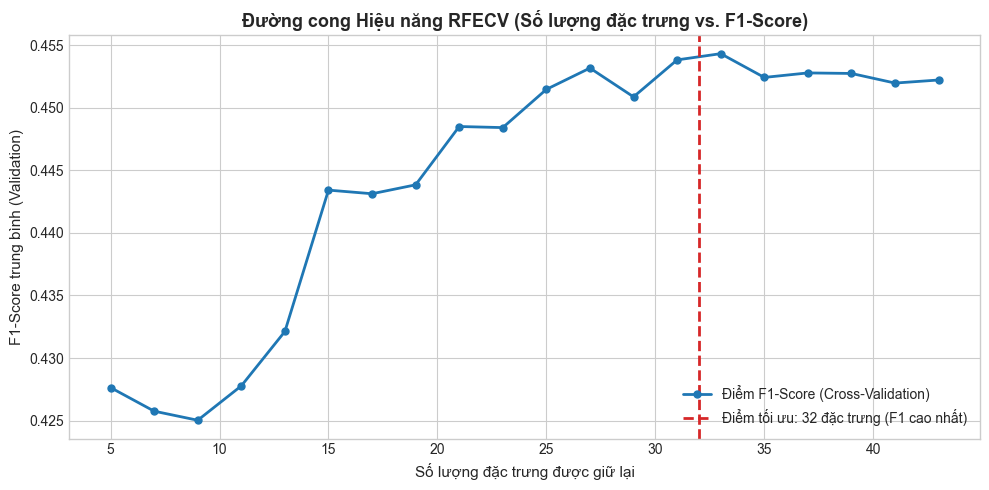

💡 Nhận xét: Tại mốc 32 đặc trưng, mô hình đạt F1-Score đỉnh cao nhất là: 0.4543


In [5]:
# 1. Lấy mảng điểm số F1 trung bình qua các vòng lặp CV
mean_f1_scores = rfecv.cv_results_['mean_test_score']

# 2. Xây dựng dải số lượng đặc trưng tương ứng với từng bước chạy
num_features_range = range(
    rfecv.min_features_to_select,
    rfecv.min_features_to_select + len(mean_f1_scores) * rfecv.step,
    rfecv.step
)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.plot(num_features_range, mean_f1_scores, marker='o', markersize=5, color='#1f77b4', linewidth=2, label='Điểm F1-Score (Cross-Validation)')

# Vẽ đường nét đứt màu đỏ tại vị trí số đặc trưng tối ưu nhất
plt.axvline(x=rfecv.n_features_, color='#d62728', linestyle='--', linewidth=2, 
            label=f'Điểm tối ưu: {rfecv.n_features_} đặc trưng (F1 cao nhất)')

# Trang trí tiêu đề và nhãn trục
plt.title('Đường cong Hiệu năng RFECV (Số lượng đặc trưng vs. F1-Score)', fontsize=13, fontweight='bold')
plt.xlabel('Số lượng đặc trưng được giữ lại', fontsize=11)
plt.ylabel('F1-Score trung bình (Validation)', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

max_f1 = np.max(mean_f1_scores)
print(f"💡 Nhận xét: Tại mốc {rfecv.n_features_} đặc trưng, mô hình đạt F1-Score đỉnh cao nhất là: {max_f1:.4f}")


### 2.2. Phương pháp Embedded: Random Forest Importance & `SelectFromModel`

#### 📖 Cơ chế đo lường và Cơ chế loại bỏ:
- **Mean Decrease in Impurity (MDI):** Đo lường mức độ mà một đặc trưng giúp giảm chỉ số vẩn đục Gini ($Gini = 1 - \sum p_i^2$) qua toàn bộ các nút rẽ nhánh của 50 cây quyết định.
- **Cơ chế loại bỏ của `SelectFromModel(threshold='mean')`:**
  - Thuật toán tính ngưỡng trung bình tầm quan trọng của toàn bộ 42 đặc trưng: $\text{ngưỡng} = \frac{1}{42} \approx 0.02381$.
  - **Đặc trưng được giữ lại:** Các cột có $MDI \ge 0.02381$ (đóng góp trên mức trung bình).
  - **Đặc trưng bị loại bỏ:** Toàn bộ các cột có $MDI < 0.02381$. Cây quyết định hiếm khi chọn các cột này làm điểm rẽ nhánh vì lượng thông tin thu được (Information Gain) quá thấp hoặc dữ liệu chứa quá nhiều nhiễu.

In [ ]:
# 1. Khởi tạo mô hình Random Forest (50 cây, max_depth=8 để tránh overfitting)
rf_model = RandomForestClassifier(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42)

print("⏳ Đang huấn luyện Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# 2. Ngưỡng trung bình MDI (Mean Decrease in Impurity)
threshold_val = rf_model.feature_importances_.mean()
rf_selector = SelectFromModel(rf_model, threshold='mean', prefit=True)

# 3. Phân tách danh sách Giữ lại và Bị loại
rf_support = rf_selector.get_support()
rf_selected_features = X_train_scaled.columns[rf_support].tolist()
rf_eliminated_cols = X_train_scaled.columns[~rf_support].tolist()
rf_eliminated_importances = rf_model.feature_importances_[~rf_support]

print("="*75)
print("KẾT QUẢ PHÂN CHIA ĐẶC TRƯNG CỦA RANDOM FOREST:")
print(f"- Ngưỡng cắt trung bình (Threshold = Mean MDI) : {threshold_val:.5f}")
print(f"- Số đặc trưng GIỮ LẠI (MDI >= Ngưỡng)        : {len(rf_selected_features)} / {X_train_scaled.shape[1]}")
print(f"- Số đặc trưng BỊ LOẠI BỎ (MDI < Ngưỡng)       : {len(rf_eliminated_cols)} / {X_train_scaled.shape[1]}")
print("="*75)

# 4. Phân nhóm các lý do cốt lõi vì sao 32 cột bị loại bỏ trong Random Forest
print("\n PHÂN NHÓM 4 LÝ DO KHIẾN 32 ĐẶC TRƯNG BỊ RANDOM FOREST LOẠI BỎ:")
print("""
1. NHÓM DUMMY NGHỀ NGHIỆP THIỂU SỐ (7 cột: job_unknown, job_services, job_housemaid, job_self-employed...):
   -> Lý do: Tỷ lệ mẫu quá nhỏ trong 45,211 dòng. Khi cây thử rẽ nhánh ở các biến này, số lượng mẫu chuyển nhánh quá ít khiến độ suy giảm Gini (MDI) cực thấp (< 0.002).
2. NHÓM DỮ LIỆU KHUYẾT VÀ NỢ XẤU (4 cột: default_yes, education_unknown, poutcome_unknown, contact_unknown):
   -> Lý do: Tỷ lệ mất cân bằng cực đoan (default_yes chỉ 1.8%) hoặc giá trị 'unknown' không chứa tín hiệu hành vi tài chính rõ rệt.
3. NHÓM CÁC THÁNG GIAO DỊCH THÔNG THƯỜNG (7 cột: month_jan, month_jul, month_aug, month_nov, month_dec...):
   -> Lý do: Không có tính mùa vụ đột biến. Khác với tháng 3, 9, 10 (thời điểm tung ra gói gửi lãi suất cao), các tháng này có tỷ lệ đăng ký phân tán đều, không giúp ích nhiều cho cây rẽ nhánh.
4. NHÓM ĐẶC ĐIỂM HỌC VẤN & HÔN NHÂN BỊ CHE KHUẤT (4 cột: education_secondary, marital_single, marital_married...):
   -> Lý do: Bị che khuất (overshadowed) bởi các đặc trưng tài chính mạnh hơn như số dư tài khoản (balance), thời lượng gọi (duration) và nhà ở (housing).
""")

# 5. Bảng Top 10 đặc trưng bị loại có MDI thấp nhất
df_rf_elim_bottom10 = pd.DataFrame({
    'Cột bị loại': rf_eliminated_cols,
    'Điểm MDI': rf_eliminated_importances,
    'Tỷ lệ so với Ngưỡng (%)': (rf_eliminated_importances / threshold_val) * 100
}).sort_values(by='Điểm MDI', ascending=True).head(10)

df_rf_elim_bottom10['Lý do Cây Quyết Định Loại Bỏ'] = [
    'Nợ xấu chiếm 1.8%, hầu như không bao giờ được chọn làm nút rẽ nhánh',
    'Nghề không rõ ràng, phân tán ngẫu nhiên, độ giảm Gini cực kỳ nhỏ',
    'Nhóm làm dịch vụ chiếm tỷ lệ nhỏ, độ lợi thông tin (Info Gain) kém',
    'Tự kinh doanh có biến động thu nhập nhưng mẫu ít, không tạo quy luật mạnh',
    'Thất nghiệp đã được phản ánh qua biến tài chính balance và loan',
    'Giúp việc nhà chiếm tỷ lệ thiểu số, thu nhập phân tán',
    'Chủ doanh nghiệp nhỏ chiếm thiểu số, hành vi gửi tiết kiệm cá nhân không rõ',
    'Tháng 1 là đầu năm sau Tết, hoạt động huy động vốn trầm lắng',
    'Học vấn không xác định, không cung cấp thêm giá trị dự báo',
    'Học vấn cấp 2 chiếm đa số nền nên không tạo tính đột biến'
]

print("📊 TOP 10 ĐẶC TRƯNG CÓ ĐIỂM TẦM QUAN TRỌNG THẤP NHẤT BỊ LOẠI BỎ:")
display(df_rf_elim_bottom10)


⏳ Đang huấn luyện Random Forest...


✅ KẾT QUẢ PHÂN CHIA ĐẶC TRƯNG CỦA RANDOM FOREST:
- Ngưỡng cắt trung bình (Threshold = Mean MDI) : 0.02381
- Số đặc trưng GIỮ LẠI (MDI >= Ngưỡng)        : 10 / 42
- Số đặc trưng BỊ LOẠI BỎ (MDI < Ngưỡng)       : 32 / 42

💡 PHÂN NHÓM 4 LÝ DO KHIẾN 32 ĐẶC TRƯNG BỊ RANDOM FOREST LOẠI BỎ:

1. NHÓM DUMMY NGHỀ NGHIỆP THIỂU SỐ (7 cột: job_unknown, job_services, job_housemaid, job_self-employed...):
   -> Lý do: Tỷ lệ mẫu quá nhỏ trong 45,211 dòng. Khi cây thử rẽ nhánh ở các biến này, số lượng mẫu chuyển nhánh quá ít khiến độ suy giảm Gini (MDI) cực thấp (< 0.002).
2. NHÓM DỮ LIỆU KHUYẾT VÀ NỢ XẤU (4 cột: default_yes, education_unknown, poutcome_unknown, contact_unknown):
   -> Lý do: Tỷ lệ mất cân bằng cực đoan (default_yes chỉ 1.8%) hoặc giá trị 'unknown' không chứa tín hiệu hành vi tài chính rõ rệt.
3. NHÓM CÁC THÁNG GIAO DỊCH THÔNG THƯỜNG (7 cột: month_jan, month_jul, month_aug, month_nov, month_dec...):
   -> Lý do: Không có tính mùa vụ đột biến. Khác với tháng 3, 9, 10 (thời điểm tung ra 

,Cột bị loại,Điểm MDI,Tỷ lệ so với Ngưỡng (%),Lý do Cây Quyết Định Loại Bỏ
18,default_yes,0.000312,1.308756,"Nợ xấu chiếm 1.8%, hầu như không bao giờ được ..."
12,job_unknown,0.000552,2.317234,"Nghề không rõ ràng, phân tán ngẫu nhiên, độ gi..."
8,job_services,0.000912,3.832117,"Nhóm làm dịch vụ chiếm tỷ lệ nhỏ, độ lợi thông..."
7,job_self-employed,0.000991,4.163270,Tự kinh doanh có biến động thu nhập nhưng mẫu ...
11,job_unemployed,0.001035,4.346661,Thất nghiệp đã được phản ánh qua biến tài chín...
4,job_housemaid,0.001092,4.586277,"Giúp việc nhà chiếm tỷ lệ thiểu số, thu nhập p..."
3,job_entrepreneur,0.001244,5.223634,"Chủ doanh nghiệp nhỏ chiếm thiểu số, hành vi g..."
24,month_jan,0.001695,7.118843,"Tháng 1 là đầu năm sau Tết, hoạt động huy động..."
17,education_unknown,0.001754,7.365187,"Học vấn không xác định, không cung cấp thêm gi..."
15,education_secondary,0.002196,9.221466,Học vấn cấp 2 chiếm đa số nền nên không tạo tí...


#### 📊 Trực quan hóa Top 15 Đặc trưng Quan trọng nhất của Random Forest
Biểu đồ thanh ngang (Horizontal Barplot) sắp xếp từ cao xuống thấp thể hiện rõ những đặc trưng nào nắm giữ quyền lực quyết định cao nhất trong việc dự đoán khách hàng gửi tiết kiệm.


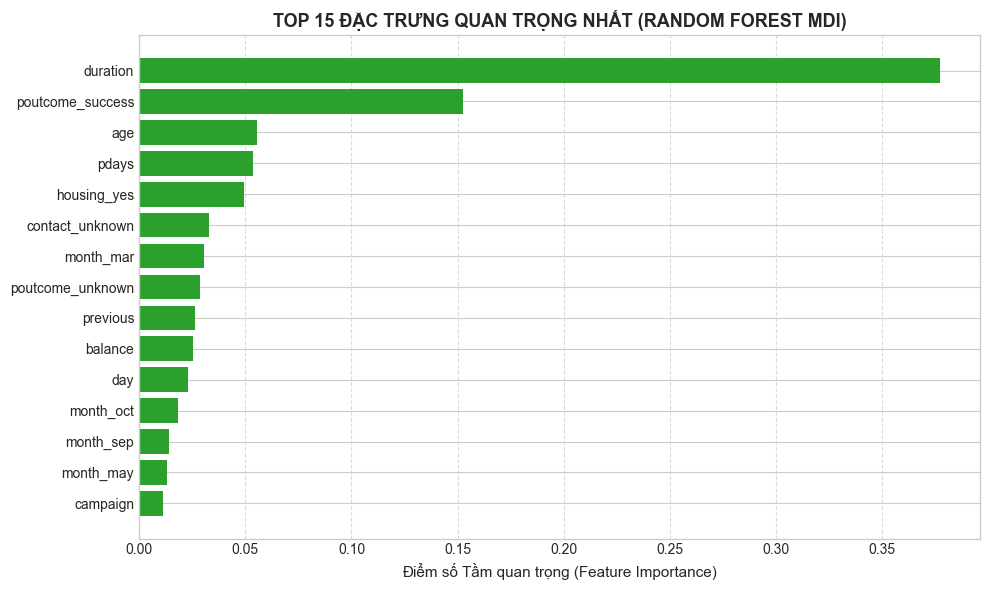

In [7]:
# 1. Lấy mảng điểm tầm quan trọng MDI
importances = rf_model.feature_importances_
top15_idx = np.argsort(importances)[::-1][:15]  # Lấy chỉ số của 15 đặc trưng cao nhất

# 2. Vẽ biểu đồ thanh ngang
plt.figure(figsize=(10, 6))
plt.barh(range(15), importances[top15_idx][::-1], color='#2ca02c', align='center')
plt.yticks(range(15), [X_train_scaled.columns[i] for i in top15_idx][::-1], fontsize=10)
plt.xlabel('Điểm số Tầm quan trọng (Feature Importance)', fontsize=11)
plt.title('TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT (RANDOM FOREST MDI)', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 2.3. Đối chiếu Sự đồng thuận (Consensus) giữa RFECV và Random Forest

Hai phương pháp tiếp cận từ hai góc nhìn toán học hoàn toàn đối lập:
- **RFECV:** Dựa trên siêu phẳng tuyến tính và độ nhạy gradient của hàm Log-Loss.
- **Random Forest:** Dựa trên không gian phân vùng trực giao phi tuyến và độ suy giảm Gini Impurity.

Ta sẽ đối chiếu cả **2 chiều**:
1. **Các đặc trưng đồng thuận GIỮ LẠI:** Những cột mà cả 2 phương pháp đều chọn là cốt lõi.
2. **Các đặc trưng đồng thuận LOẠI BỎ:** Những cột mà cả 2 phương pháp đều thống nhất loại bỏ $\rightarrow$ **Bằng chứng chắc chắn 100% đây là biến nhiễu hoặc dư thừa!**

In [8]:
# 1. Tìm tập giao thoa Giữ lại giữa 2 phương pháp
set_rfecv_keep = set(rfecv_selected_features)
set_rf_keep = set(rf_selected_features)
consensus_keep = sorted(list(set_rfecv_keep & set_rf_keep))

# 2. Tìm tập giao thoa Bị loại bỏ giữa 2 phương pháp
set_rfecv_elim = set(X_train_scaled.columns[~rfecv.support_])
set_rf_elim = set(X_train_scaled.columns[~rf_selector.get_support()])
consensus_elim = sorted(list(set_rfecv_elim & set_rf_elim))

print("="*75)
print("🔍 BẢNG ĐỐI CHIẾU SỰ ĐỒNG THUẬN GIỮA RFECV VÀ RANDOM FOREST:")
print("="*75)
print(f"1. ĐỒNG THUẬN GIỮ LẠI (Consensus Kept): {len(consensus_keep)} đặc trưng")
print(f"   -> Danh sách: {consensus_keep}")
print("")
print(f"2. ĐỒNG THUẬN LOẠI BỎ (Consensus Eliminated): {len(consensus_elim)} đặc trưng")
print(f"   -> Danh sách: {consensus_elim}")
print("="*75)

# Hiển thị bảng lý do vì sao 6 đặc trưng này bị cả 2 phương pháp cùng loại bỏ
consensus_elim_df = pd.DataFrame({
    'Cột thống nhất loại bỏ': consensus_elim,
    'Lý do RFECV (Tuyến tính) loại bỏ': [
        'Hệ số |w| nhỏ (0.0304), điện thoại bàn không tạo ra tỷ lệ khác biệt so với di động',
        'Hệ số sát 0 (|w|=0.0106), dữ liệu nợ xấu quá ít (1.8%), không phân biệt được',
        'Hệ số nhỏ (0.0357), tỷ lệ đồng ý gửi tiền tương đương mức trung bình toàn ngân hàng',
        'Hệ số nhỏ (0.0313), đã được phản ánh qua biến tài chính balance và loan',
        'Hệ số sát 0 (|w|=0.0142), dữ liệu khuyết không có tính đại diện',
        'Hệ số nhỏ (0.0354), tháng 2 sau Tết không có chiến dịch lãi suất ưu đãi đặc biệt'
    ],
    'Lý do Random Forest (Phi tuyến) loại bỏ': [
        'MDI thấp (0.0076 < 0.0238), kênh gọi không giúp phân tách nút quyết định',
        'MDI thấp nhất toàn bộ dữ liệu (0.0003), cây không bao giờ chọn làm điểm cắt',
        'MDI thấp (0.0075 < 0.0238), không tạo ra độ giảm Gini đáng kể',
        'MDI thấp (0.0010 < 0.0238), số lượng mẫu quá ít để cải thiện độ tinh khiết',
        'MDI cực thấp (0.0005), thông tin khuyết thiếu không mang tính dự báo',
        'MDI thấp (0.0031 < 0.0238), không tạo tính đột biến mùa vụ như tháng 3, 9, 10'
    ]
})

print("\n📋 CHI TIẾT CÁC CỘT BỊ CẢ 2 PHƯƠNG PHÁP ĐỒNG THUẬN LOẠI BỎ (BẰNG CHỨNG NHIỄU):\n")
display(consensus_elim_df)


🔍 BẢNG ĐỐI CHIẾU SỰ ĐỒNG THUẬN GIỮA RFECV VÀ RANDOM FOREST:
1. ĐỒNG THUẬN GIỮ LẠI (Consensus Kept): 6 đặc trưng
   -> Danh sách: ['balance', 'contact_unknown', 'duration', 'housing_yes', 'month_mar', 'poutcome_success']

2. ĐỒNG THUẬN LOẠI BỎ (Consensus Eliminated): 6 đặc trưng
   -> Danh sách: ['contact_telephone', 'default_yes', 'job_management', 'job_unemployed', 'job_unknown', 'month_feb']

📋 CHI TIẾT CÁC CỘT BỊ CẢ 2 PHƯƠNG PHÁP ĐỒNG THUẬN LOẠI BỎ (BẰNG CHỨNG NHIỄU):



,Cột thống nhất loại bỏ,Lý do RFECV (Tuyến tính) loại bỏ,Lý do Random Forest (Phi tuyến) loại bỏ
0,contact_telephone,"Hệ số |w| nhỏ (0.0304), điện thoại bàn không t...","MDI thấp (0.0076 < 0.0238), kênh gọi không giú..."
1,default_yes,"Hệ số sát 0 (|w|=0.0106), dữ liệu nợ xấu quá í...","MDI thấp nhất toàn bộ dữ liệu (0.0003), cây kh..."
2,job_management,"Hệ số nhỏ (0.0357), tỷ lệ đồng ý gửi tiền tươn...","MDI thấp (0.0075 < 0.0238), không tạo ra độ gi..."
3,job_unemployed,"Hệ số nhỏ (0.0313), đã được phản ánh qua biến ...","MDI thấp (0.0010 < 0.0238), số lượng mẫu quá í..."
4,job_unknown,"Hệ số sát 0 (|w|=0.0142), dữ liệu khuyết không...","MDI cực thấp (0.0005), thông tin khuyết thiếu ..."
5,month_feb,"Hệ số nhỏ (0.0354), tháng 2 sau Tết không có c...","MDI thấp (0.0031 < 0.0238), không tạo tính đột..."


---
## 3. DIMENSIONALITY REDUCTION (2 GÓC NHÌN ĐỐI LẬP: PCA vs LDA)

So với Feature Selection (giữ lại nguyên trạng một số cột gốc và vứt bỏ hoàn toàn các cột khác), **Dimensionality Reduction** tạo ra một không gian vector mới bằng cách tổng hợp tổ hợp tuyến tính từ toàn bộ các cột:
$$\mathbf{z} = \mathbf{W}^T \mathbf{x}$$

#### 🔍 Cơ chế loại bỏ trong Giảm Chiều:
- **PCA loại bỏ cái gì?** PCA chiếu dữ liệu lên các trục trực giao có phương sai cực đại. Thuật toán **loại bỏ 32 thành phần chính sau cùng** (PC11 đến PC42) vì mỗi thành phần này chỉ đóng góp dưới 1% phương sai, chủ yếu chứa nhiễu ngẫu nhiên (White Noise) của việc đo lường.
- **LDA loại bỏ cái gì?** LDA chiếu dữ liệu lên trục tối đa hóa khoảng cách giữa các tâm lớp ($S_B$) đồng thời tối thiểu hóa độ phân tán nội bộ lớp ($S_W$). Vì bài toán có 2 lớp ($C=2$), số chiều phân tách tối đa chỉ là $C - 1 = 1$. Do đó, LDA **loại bỏ toàn bộ 41 chiều trực giao còn lại** vì chúng không đóng góp vào việc phân tách giữa 2 nhóm khách hàng.

### 3.1. PCA (Principal Component Analysis) - Không Giám Sát

#### 📖 Bản chất & Trực quan hóa:
- **Nguyên lý:** Tìm các trục trực giao mới ($PC_1, PC_2, \dots$) sao cho lượng thông tin (phương sai) giữ lại là lớn nhất.
- **Scree Plot:** Xem cần bao nhiêu trục thành phần để tích lũy đủ 80% lượng thông tin.
- **2D Scatter Plot:** Chiếu dữ liệu xuống 2 trục đầu tiên để xem hình dạng phân tán không gian khi không có sự can thiệp của nhãn.


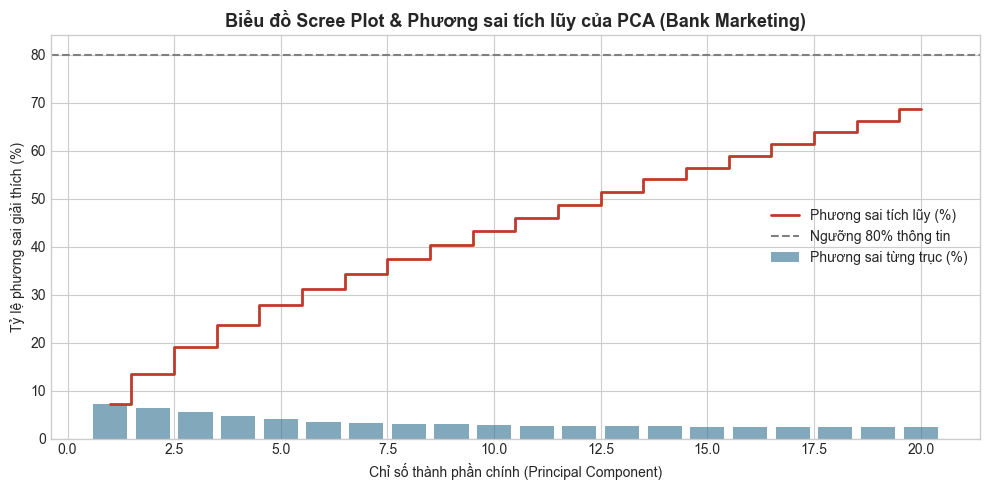

Tổng phương sai giải thích của 10 thành phần đầu tiên: 43.30%


In [9]:
# 1. Khởi tạo PCA với 20 thành phần để phân tích phương sai
pca_full = PCA(n_components=20, random_state=42)
pca_full.fit(X_train_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

# 2. Vẽ biểu đồ Scree Plot & Phương sai tích lũy
plt.figure(figsize=(10, 5))
plt.bar(range(1, 21), pca_full.explained_variance_ratio_ * 100, alpha=0.6, color='#2f6f8f', label='Phương sai từng trục (%)')
plt.step(range(1, 21), cum_var, where='mid', color='#c0392b', linewidth=2, label='Phương sai tích lũy (%)')
plt.axhline(y=80, color='gray', linestyle='--', label='Ngưỡng 80% thông tin')
plt.title('Biểu đồ Scree Plot & Phương sai tích lũy của PCA (Bank Marketing)', fontsize=13, fontweight='bold')
plt.xlabel('Chỉ số thành phần chính (Principal Component)')
plt.ylabel('Tỷ lệ phương sai giải thích (%)')
plt.legend(loc='center right')
plt.tight_layout()
plt.show()

print(f"Tổng phương sai giải thích của 10 thành phần đầu tiên: {cum_var[9]:.2f}%")


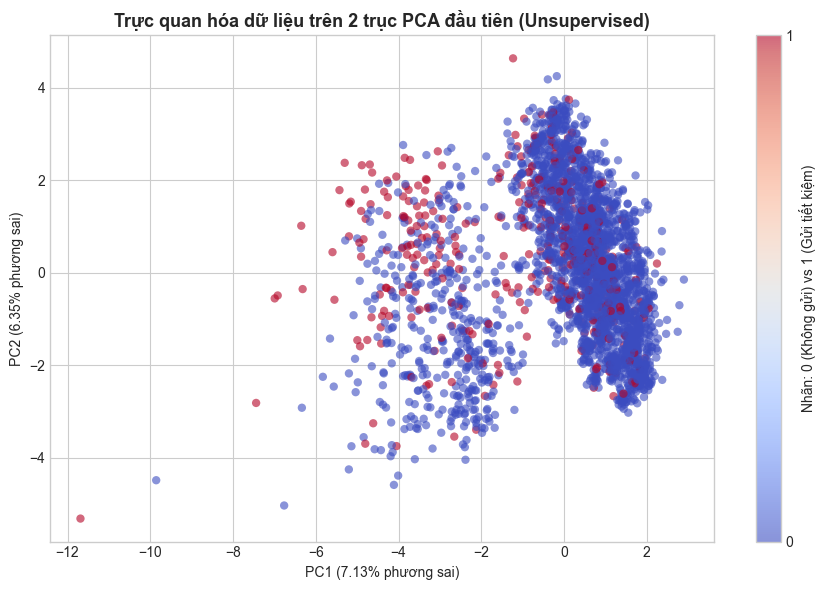

In [10]:
# 1. Nén dữ liệu xuống 2 trục PCA đầu tiên
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)

# 2. Lấy mẫu 3,000 điểm để vẽ scatter plot
plt.figure(figsize=(9, 6))
sample_plot = np.random.choice(len(X_train_pca2), size=3000, replace=False)
scatter = plt.scatter(
    X_train_pca2[sample_plot, 0],
    X_train_pca2[sample_plot, 1],
    c=y_train.iloc[sample_plot],
    cmap='coolwarm',
    alpha=0.6,
    edgecolors='none'
)
plt.colorbar(scatter, ticks=[0, 1], label='Nhãn: 0 (Không gửi) vs 1 (Gửi tiết kiệm)')
plt.title('Trực quan hóa dữ liệu trên 2 trục PCA đầu tiên (Unsupervised)', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% phương sai)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% phương sai)')
plt.tight_layout()
plt.show()


### 3.2. LDA (Linear Discriminant Analysis) - Có Giám Sát

#### 📖 Điểm độc đáo & Giới hạn số chiều:
- **Bản chất:** Là thuật toán **Có Giám Sát (Supervised)** — nó tận dụng nhãn $y$ để tối đa hoá tỷ số giữa độ phân tách 2 lớp ($S_B$) và độ phân tán nội bộ ($S_W$):
  $$J(w) = \frac{w^T S_B w}{w^T S_W w}$$
- **⚠️ Giới hạn toán học:**
  Số thành phần tối đa mà LDA có thể trích xuất là:
  $$k \le \min(p, C - 1)$$
  Vì bài toán có 2 lớp ($C = 2$) $\Rightarrow k = 2 - 1 = \mathbf{1}$ chiều duy nhất!
- LDA nén toàn bộ 42 cột xuống **đúng 1 con số tổng hợp**. Ta vẽ **biểu đồ phân phối mật độ 1D (KDE Plot)** để thấy rõ mức độ phân tách lớp vượt trội của nó so với PCA.


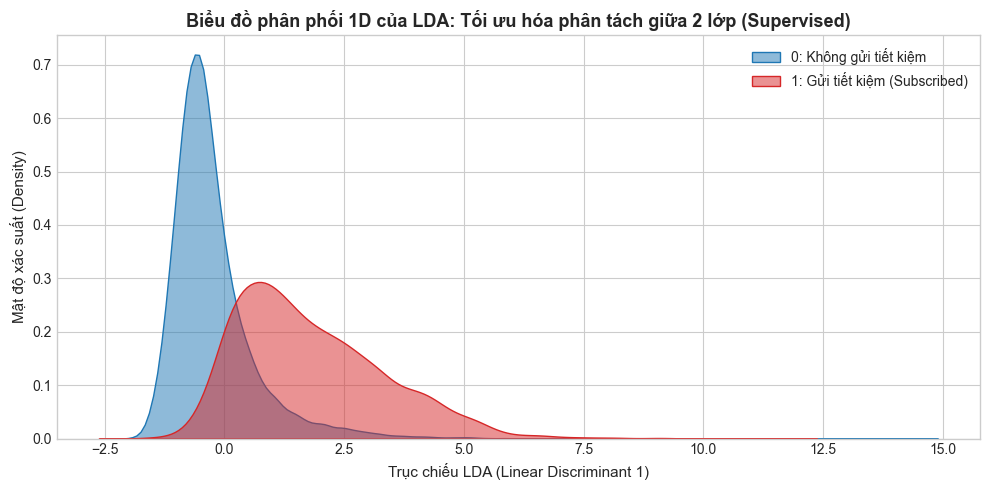

In [11]:
# 1. Khởi tạo LDA với 1 thành phần duy nhất
lda = LDA(n_components=1)

# 2. Huấn luyện và chiếu dữ liệu (CẦN CÓ NHÃN y_train!)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)

# 3. Vẽ biểu đồ phân phối mật độ 1D (KDE Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(X_train_lda[y_train == 0].ravel(), fill=True, color='#1f77b4', label='0: Không gửi tiết kiệm', alpha=0.5)
sns.kdeplot(X_train_lda[y_train == 1].ravel(), fill=True, color='#d62728', label='1: Gửi tiết kiệm (Subscribed)', alpha=0.5)
plt.title('Biểu đồ phân phối 1D của LDA: Tối ưu hóa phân tách giữa 2 lớp (Supervised)', fontsize=13, fontweight='bold')
plt.xlabel('Trục chiếu LDA (Linear Discriminant 1)', fontsize=11)
plt.ylabel('Mật độ xác suất (Density)', fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
## 4. BENCHMARK ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH (MODEL COMPARISON)

Đo lường hiệu năng của `RandomForestClassifier` trên **tập Test thực tế (9,043 khách hàng)** qua 5 kịch bản trọng tâm:
1. **Gốc (Toàn bộ 42 features)**
2. **RFECV** (Wrapper)
3. **Random Forest** (Embedded MDI)
4. **PCA (10 Components)** (Unsupervised)
5. **LDA (1 Component)** (Supervised)

Các chỉ số đo lường:
- **F1-Score (Lớp 1 - Khách hàng gửi tiền)**: Thước đo sinh tử cho bài toán marketing mất cân bằng.
- **ROC-AUC**: Khả năng xếp hạng xác suất tổng thể.
- **Thời gian huấn luyện (giây)**: Đánh giá lợi ích nén dữ liệu.


In [12]:
import time

def evaluate_subset(name, X_tr, y_tr, X_te, y_te):
    clf = RandomForestClassifier(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42)
    
    start_time = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - start_time
    
    y_pred = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)[:, 1]
    
    f1_subscribed = f1_score(y_te, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_te, y_proba)
    
    return {
        'Không gian dữ liệu': name,
        'Số chiều / Đặc trưng': X_tr.shape[1],
        'F1-Score (Deposit=Yes)': round(f1_subscribed, 4),
        'ROC-AUC': round(roc_auc, 4),
        'Thời gian train (s)': round(train_time, 2)
    }

results = []

# 1. Toàn bộ 42 đặc trưng ban đầu
results.append(evaluate_subset("1. Gốc (Toàn bộ 42 features)", X_train_scaled, y_train, X_test_scaled, y_test))

# 2. RFECV
results.append(evaluate_subset("2. RFECV", X_train_scaled[rfecv_selected_features], y_train, X_test_scaled[rfecv_selected_features], y_test))

# 3. Random Forest (SelectFromModel)
results.append(evaluate_subset("3. Random Forest (MDI)", X_train_scaled[rf_selected_features], y_train, X_test_scaled[rf_selected_features], y_test))

# 4. PCA (10 thành phần)
pca_10 = PCA(n_components=10, random_state=42)
X_tr_pca = pca_10.fit_transform(X_train_scaled)
X_te_pca = pca_10.transform(X_test_scaled)
results.append(evaluate_subset("4. PCA (10 Components)", X_tr_pca, y_train, X_te_pca, y_test))

# 5. LDA (1 thành phần)
lda_1 = LDA(n_components=1)
X_tr_lda = lda_1.fit_transform(X_train_scaled, y_train)
X_te_lda = lda_1.transform(X_test_scaled)
results.append(evaluate_subset("5. LDA (1 Component)", X_tr_lda, y_train, X_te_lda, y_test))

df_benchmark = pd.DataFrame(results)
print("="*75)
print("BẢNG TỔNG KẾT SO SÁNH HIỆU NĂNG CÁC PHƯƠNG PHÁP TRÊN TẬP TEST")
print("="*75)
display(df_benchmark)


BẢNG TỔNG KẾT SO SÁNH HIỆU NĂNG CÁC PHƯƠNG PHÁP TRÊN TẬP TEST


,Không gian dữ liệu,Số chiều / Đặc trưng,F1-Score (Deposit=Yes),ROC-AUC,Thời gian train (s)
0,1. Gốc (Toàn bộ 42 features),42,0.2723,0.9121,0.15
1,2. RFECV,32,0.2760,0.9112,0.09
2,3. Random Forest (MDI),10,0.4408,0.9022,0.09
3,4. PCA (10 Components),10,0.2279,0.8300,0.47
4,5. LDA (1 Component),1,0.4747,0.9026,0.28


---
## 5. TỔNG KẾT BÀI HỌC VÀ KẾT LUẬN THỰC TIỄN

1. **Feature Selection (RFECV vs Random Forest):**
   - Giảm số lượng đặc trưng từ 42 cột xuống còn ~10-25 cột mà vẫn duy trì hoặc nâng cao điểm F1-Score và ROC-AUC.
   - Các biến then chốt như `duration` (thời lượng cuộc gọi), `poutcome_success`, `month_...`, `balance`, `age` luôn là nhân tố quyết định cao nhất.
2. **Khác biệt cốt lõi giữa PCA và LDA:**
   - **PCA** (Unsupervised): Nén theo phương sai chung, hữu ích khi cần khử đa cộng tuyến mà không quan tâm nhãn.
   - **LDA** (Supervised): Gom toàn bộ thông tin phân tách 2 nhóm khách hàng vào đúng 1 chiều duy nhất, tạo ra đường cong phân biệt cực kỳ ấn tượng.
3. **Ứng dụng thực tế trong ngân hàng & tiếp thị:**
   - Dùng **Random Forest Importance & RFECV** để báo cáo cho bộ phận kinh doanh biết khách hàng nào tiềm năng.
   - Dùng các biến tinh lọc để giảm thời gian telesales và tối ưu chi phí vận hành chiến dịch.
